In [3]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print("Setup Complete")



Setup Complete


In [4]:
import os
datatrain_path = "diabetes_prediction_dataset.csv"
if not os.path.exists(datatrain_path):
   print("Dataset gk ada")

datatrain = pd.read_csv(datatrain_path)
datatrain.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# 1. Exploratory Data Analysis (EDA)

In [5]:
datatrain.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [6]:
datatrain.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [7]:
datatrain['smoking_history'].unique()

<StringArray>
['never', 'No Info', 'current', 'former', 'ever', 'not current']
Length: 6, dtype: str

In [8]:
datatrain['gender'].unique()

<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

In [9]:
datatrain.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

<Axes: >

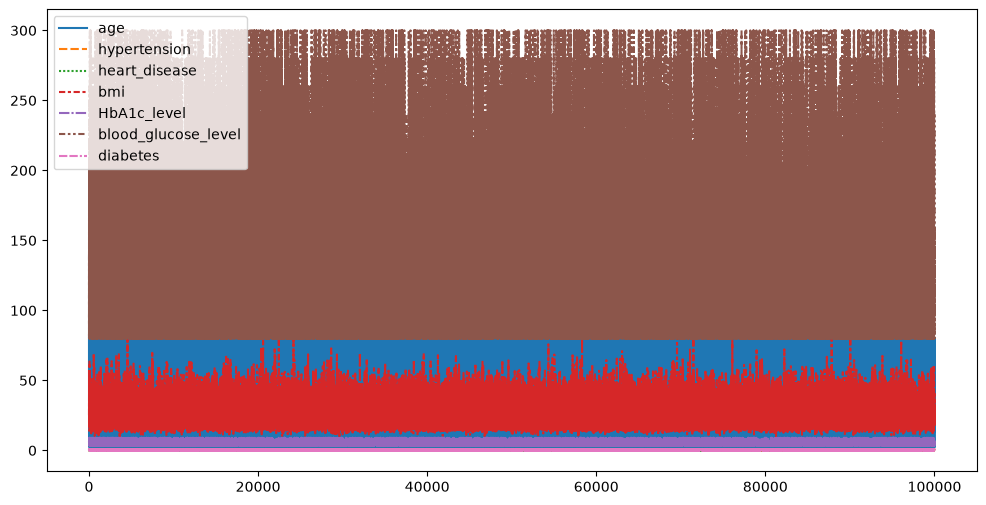

In [10]:
plt.figure(figsize=(12,6))
sns.lineplot(data=datatrain)



# 2. Preprocessing

In [11]:
datatrain['gender'].value_counts()

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

In [12]:
datatrain = pd.get_dummies(datatrain, columns=['gender'], dtype=int)

In [13]:
datatrain

,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other
0,80.0,0,1,never,25.19,6.6,140,0,1,0,0
1,54.0,0,0,No Info,27.32,6.6,80,0,1,0,0
2,28.0,0,0,never,27.32,5.7,158,0,0,1,0
3,36.0,0,0,current,23.45,5.0,155,0,1,0,0
4,76.0,1,1,current,20.14,4.8,155,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
99995,80.0,0,0,No Info,27.32,6.2,90,0,1,0,0
99996,2.0,0,0,No Info,17.37,6.5,100,0,1,0,0
99997,66.0,0,0,former,27.83,5.7,155,0,0,1,0
99998,24.0,0,0,never,35.42,4.0,100,0,1,0,0


In [14]:
datatrain = pd.get_dummies(
    datatrain,
    columns=['smoking_history'],
    dtype=int
)

In [15]:
datatrain

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,1,0,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,1,0,0,1,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,0,1,0,0,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,1,0,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,80.0,0,0,27.32,6.2,90,0,1,0,0,1,0,0,0,0,0
99996,2.0,0,0,17.37,6.5,100,0,1,0,0,1,0,0,0,0,0
99997,66.0,0,0,27.83,5.7,155,0,0,1,0,0,0,0,1,0,0
99998,24.0,0,0,35.42,4.0,100,0,1,0,0,0,0,0,0,1,0


In [16]:
X = datatrain.drop('diabetes', axis=1)
y = datatrain['diabetes']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
import time
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),
    "SVM": SVC(
        probability=True,
        random_state=42
    ),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")

    start = time.time()

    try:
        # Training
        model.fit(X_train_scaled, y_train)

        # Prediksi training
        pred_train = model.predict(X_train_scaled)

        # Prediksi test
        pred_test = model.predict(X_test_scaled)

        # Metric training
        train_acc = accuracy_score(y_train, pred_train)

        # Metric test
        test_acc = accuracy_score(y_test, pred_test)
        precision = precision_score(y_test, pred_test)
        recall = recall_score(y_test, pred_test)
        f1 = f1_score(y_test, pred_test)

        elapsed = time.time() - start

        results.append({
            "Model": name,
            "Train Accuracy": train_acc,
            "Test Accuracy": test_acc,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Time (s)": elapsed
        })

        print(f"Train Accuracy : {train_acc:.4f}")
        print(f"Test Accuracy  : {test_acc:.4f}")
        print(f"Precision      : {precision:.4f}")
        print(f"Recall         : {recall:.4f}")
        print(f"F1 Score       : {f1:.4f}")
        print(f"Time           : {elapsed:.2f}s")

    except Exception as e:
        print(f"Error pada model {name}: {e}")

results_df = pd.DataFrame(results)

print("\n=== HASIL PERBANDINGAN MODEL ===")
print(results_df.sort_values(by="F1 Score", ascending=False))


Training RandomForest...
Train Accuracy : 0.9992
Test Accuracy  : 0.9701
Precision      : 0.9451
Recall         : 0.6888
F1 Score       : 0.7969
Time           : 6.22s

Training XGBoost...
Train Accuracy : 0.9760
Test Accuracy  : 0.9708
Precision      : 0.9457
Recall         : 0.6971
F1 Score       : 0.8026
Time           : 1.31s

Training SVM...


/home/shala/Desktop/matakuliah/AI/tubes_ai/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Train Accuracy : 0.9635
Test Accuracy  : 0.9633
Precision      : 0.9662
Recall         : 0.5888
F1 Score       : 0.7317
Time           : 191.54s

Training KNN...
Train Accuracy : 0.9691
Test Accuracy  : 0.9605
Precision      : 0.8798
Recall         : 0.6200
F1 Score       : 0.7274
Time           : 33.94s

=== HASIL PERBANDINGAN MODEL ===
          Model  Train Accuracy  Test Accuracy  Precision    Recall  F1 Score  \
1       XGBoost        0.976050        0.97085   0.945730  0.697059  0.802574   
0  RandomForest        0.999200        0.97015   0.945117  0.688824  0.796870   
2           SVM        0.963512        0.96330   0.966216  0.588824  0.731725   
3           KNN        0.969100        0.96050   0.879800  0.620000  0.727398   

     Time (s)  
1    1.310237  
0    6.220286  
2  191.538098  
3   33.941513  


In [49]:
import joblib

joblib.dump(models["XGBoost"], "diabetes_xgboost.pkl")
joblib.dump(scaler, "diabetes_scaler.pkl")

['diabetes_scaler.pkl']